In [39]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import joblib


In [40]:
# load data
files = [f"../data/hand_log{i}.csv" for i in range(2, 9, 2)]
df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)
print(len(df))
df.head(10)


410876


,round_id,player_id,dealer_upcard,dealer_hand_value,hand_start_value,hand_final_value,hand_result,actions,cards,bet,profit/loss
0,1,0,6,19,8,17,Loss,HS,"[2, 6, 9]",1,-1.0
1,2,0,3,23,20,20,Win,S,"['K', 'J']",1,1.0
2,3,0,2,22,13,13,Win,S,"['Q', 3]",1,1.0
3,4,0,10,20,16,25,Bust,H,"['Q', 6, 9]",1,-1.0
4,5,0,4,22,12,12,Win,S,"[8, 4]",1,1.0
5,6,0,8,13,18,23,Bust,D,"[8, 'J', 5]",2,-2.0
6,7,0,1,19,15,21,Win,HS,"[7, 8, 6]",1,1.0
7,8,0,9,26,18,18,Win,PS,"[8, 10]",1,1.0
8,8,0,9,26,17,17,Win,S,"[8, 9]",1,1.0
9,9,0,4,24,21,21,Blackjack,NaN,"['A', 'Q']",1,1.5


In [41]:
# add columsn for is_soft, convert profit loss into win or not, dealer ace
total_df = df.copy()

total_df["cards2"] = total_df.cards.str.replace(",", "")
total_df["cards2"] = total_df.cards2.str.replace(" ", "").replace("'", "")
total_df["cards2"] = total_df.cards2.str.replace("'", "")
total_df["cards2"] = total_df.cards2.str.strip("[]")

total_df["is_soft"] = 0
total_df.loc[(total_df["cards2"].str.get(0) == "A") | (total_df["cards2"].str.get(1) == "A"), "is_soft"] = 1
total_df.loc[total_df["hand_start_value"] == 21, "is_soft"] = 1

#total_df.loc[total_df["cards"].str[2] == "A", "is_soft"] = 1
#total_df.loc[total_df["cards"].str.get(1) == "A", "is_soft"] = 1


total_df.loc[total_df["profit/loss"] > 0, "is_win"] =  1
total_df.loc[total_df["profit/loss"] <= 0, "is_win"] =  0

total_df.loc[total_df["dealer_upcard"] == 1, "dealer_ace"] = 1
total_df.loc[total_df["dealer_upcard"] != 1, "dealer_ace"] = 0

total_df.loc[total_df["hand_start_value"] == 21, "blackjack"] = 1
total_df.loc[total_df["hand_start_value"] != 21, "blackjack"] = 0
 
no_push_df = total_df[total_df["hand_result"] != "Push"]
print(no_push_df[no_push_df["hand_result"].isna()])
total_df["hand_result"].isna().sum()





total_df.head(20)

Empty DataFrame
Columns: [round_id, player_id, dealer_upcard, dealer_hand_value, hand_start_value, hand_final_value, hand_result, actions, cards, bet, profit/loss, cards2, is_soft, is_win, dealer_ace, blackjack]
Index: []


,round_id,player_id,dealer_upcard,dealer_hand_value,hand_start_value,hand_final_value,hand_result,actions,cards,bet,profit/loss,cards2,is_soft,is_win,dealer_ace,blackjack
0,1,0,6,19,8,17,Loss,HS,"[2, 6, 9]",1,-1.0,269,0,0.0,0.0,0.0
1,2,0,3,23,20,20,Win,S,"['K', 'J']",1,1.0,KJ,0,1.0,0.0,0.0
2,3,0,2,22,13,13,Win,S,"['Q', 3]",1,1.0,Q3,0,1.0,0.0,0.0
3,4,0,10,20,16,25,Bust,H,"['Q', 6, 9]",1,-1.0,Q69,0,0.0,0.0,0.0
4,5,0,4,22,12,12,Win,S,"[8, 4]",1,1.0,84,0,1.0,0.0,0.0
5,6,0,8,13,18,23,Bust,D,"[8, 'J', 5]",2,-2.0,8J5,0,0.0,0.0,0.0
6,7,0,1,19,15,21,Win,HS,"[7, 8, 6]",1,1.0,786,0,1.0,1.0,0.0
7,8,0,9,26,18,18,Win,PS,"[8, 10]",1,1.0,810,0,1.0,0.0,0.0
8,8,0,9,26,17,17,Win,S,"[8, 9]",1,1.0,89,0,1.0,0.0,0.0
9,9,0,4,24,21,21,Blackjack,NaN,"['A', 'Q']",1,1.5,AQ,1,1.0,0.0,1.0


In [42]:
total_df.drop(labels=["round_id", "player_id", "bet", "hand_final_value", 
                      "dealer_hand_value", "actions", "profit/loss", "cards", "hand_result"], axis=1, inplace=True)
total_df.head(5)

,dealer_upcard,hand_start_value,cards2,is_soft,is_win,dealer_ace,blackjack
0,6,8,269,0,0.0,0.0,0.0
1,3,20,KJ,0,1.0,0.0,0.0
2,2,13,Q3,0,1.0,0.0,0.0
3,10,16,Q69,0,0.0,0.0,0.0
4,4,12,84,0,1.0,0.0,0.0


In [43]:
# Model 1: baseline, only dealer upcard and start hand value

X_base = total_df[["dealer_upcard","hand_start_value"]]
Y = total_df[["is_win"]]
X_train, X_test, Y_train, Y_test = train_test_split(X_base, Y, train_size=0.8)

model_1 = sm.Logit(Y_train, X_train).fit()
predictions_base = model_1.predict(X_test)
y_hat_base = list(map(round, predictions_base))
accuracy_score(Y_test, y_hat_base)



Optimization terminated successfully.
         Current function value: 0.676825
         Iterations 4


0.5491627725856698

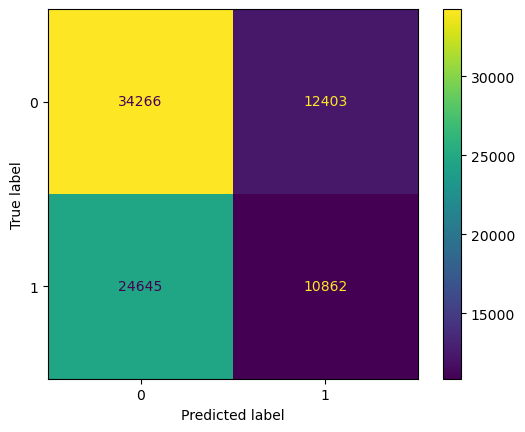

In [44]:
conf_matrix = confusion_matrix(Y_test, y_hat_base)
display = ConfusionMatrixDisplay(conf_matrix)
display.plot()
plt.show()

In [45]:
# Model 2: no push hands in data set
X = no_push_df[["dealer_upcard","hand_start_value", "is_soft", "dealer_ace", "blackjack"]]
Y = no_push_df[["is_win"]]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)
model_2 = sm.Logit(Y_train, X_train).fit()
predictions = model_2.predict(X_test)
y_hat = list(map(round, predictions))
accuracy_score(Y_test, y_hat)


Optimization terminated successfully.
         Current function value: 0.641663
         Iterations 7


0.6113681515753543

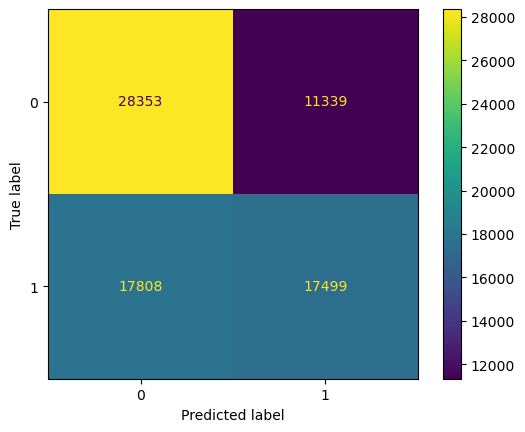

In [46]:
conf_matrix = confusion_matrix(Y_test, y_hat)
display = ConfusionMatrixDisplay(conf_matrix)
display.plot()
plt.show()

In [47]:
from sklearn.linear_model import LogisticRegression
model_3 = LogisticRegression()
model_3.fit(X_train, Y_train)
predictions = model_3.predict(X_test)
y_hat = list(map(round, predictions))
model_3.score(X_test, Y_test)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.6413685515806877

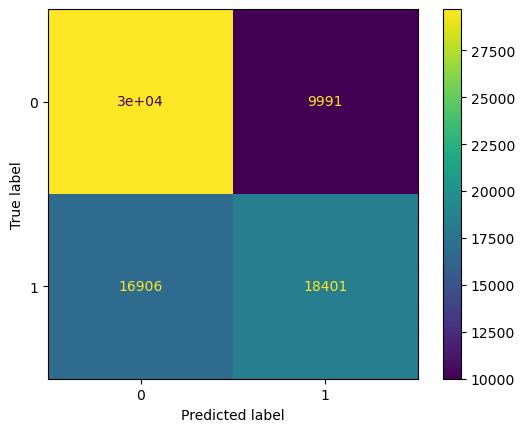

In [48]:
conf_matrix = confusion_matrix(Y_test, y_hat)
display = ConfusionMatrixDisplay(conf_matrix)
display.plot()
plt.show()

In [55]:
# Test models 
test_data = {"dealer_upcard": 1, "hand_start_value": 21, "is_soft": 1, "dealer_ace": 0, "blackjack": 1}
X_cols = ["dealer_upcard", "hand_start_value", "is_soft", "dealer_ace", "blackjack"]
test_df = pd.DataFrame([test_data])

print("Statsmodels model prediction:", model_2.predict(test_df))
print("Sklearn model prediction:", model_3.predict_proba(test_df))


Statsmodels model prediction: 0    0.974982
dtype: float64
Sklearn model prediction: [[0.03114348 0.96885652]]


In [50]:
model_2.params

dealer_upcard      -0.124786
hand_start_value    0.049192
is_soft             0.229426
dealer_ace         -1.564165
blackjack           2.525138
dtype: float64

In [51]:
model_3.coef_

array([[-0.09109452,  0.09077149,  0.18475125, -1.34306218,  2.30579911]])

In [52]:
print(model_2.summary())


                           Logit Regression Results                           
Dep. Variable:                 is_win   No. Observations:               299996
Model:                          Logit   Df Residuals:                   299991
Method:                           MLE   Df Model:                            4
Date:                Thu, 15 Jan 2026   Pseudo R-squ.:                 0.07219
Time:                        20:55:54   Log-Likelihood:            -1.9250e+05
converged:                       True   LL-Null:                   -2.0747e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
dealer_upcard       -0.1248      0.001   -103.258      0.000      -0.127      -0.122
hand_start_value     0.0492      0.001     80.570      0.000       0.048       0.050
is_soft              0.2294 

In [53]:
joblib.dump(model_3, "model_3_log_reg.pkl")

['model_3_log_reg.pkl']